# Modelación con tres algoritmos

En esta etapa se comparan tres algoritmos para reconocer cuál de las 16 actividades de entrenamiento de REHAB corresponde a cada observación preparada durante el ETL. Todos utilizan exactamente los mismos conjuntos de entrenamiento y prueba para que la comparación sea justa.


## Librerías necesarias

Se utilizarán Pandas y NumPy para cargar los datos, Seaborn y Matplotlib para visualizar los resultados, y Scikit-learn para construir y evaluar los tres clasificadores.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    validation_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

sns.set_theme(style="white")

## 1. Tipo de problema

El objetivo es predecir la actividad realizada a partir de sus características estadísticas. Como cada observación ya tiene una etiqueta conocida durante el entrenamiento, se trata de **aprendizaje supervisado**. Además, existen 16 etiquetas posibles (`000` a `015`), por lo que el problema es de **clasificación multiclase**.

La salida esperada del modelo es una sola etiqueta de actividad para cada observación de entrada.


## 2. Tipo de datos y modelos compatibles

Después del ETL, cada fila representa una ventana independiente de 220 puntos y contiene **120 características numéricas**: diez estadísticas calculadas para cada uno de los 12 canales de los dos grupos de sensores. La columna `actividad` es categórica y funciona como etiqueta.

Esta estructura corresponde a datos tabulares numéricos. Es compatible con modelos como regresión logística, KNN, SVM, árboles de decisión y Random Forest. En este notebook no se utilizan redes neuronales recurrentes o convolucionales porque esas técnicas suelen trabajar directamente con la secuencia temporal, mientras que aquí los 220 puntos ya fueron resumidos mediante características estadísticas.

Las actividades no tienen exactamente la misma cantidad de observaciones. Por ello, además de la exactitud se utilizará el **F1-score macro**, que calcula el desempeño de cada actividad por separado y después les da el mismo peso.


## 3. Carga de los datos preparados

Se cargarán `datos_train.csv` y `datos_test.csv`. Ambos archivos contienen las 120 características estadísticas y la etiqueta `actividad` como última columna.

Para entrenar los modelos, las características se separarán en `X_train` y `X_test`, mientras que las etiquetas se guardarán en `y_train` y `y_test`. Esta separación no modifica los datos; solamente distingue las entradas de la respuesta que se desea predecir.


In [2]:
# Ruta de la carpeta creada durante el ETL.
RUTA_DATOS_MODELO = Path("../Datos modelo")

# Cargamos ambos conjuntos y conservamos las actividades
# como texto para mantener los ceros iniciales.
datos_train = pd.read_csv(
    RUTA_DATOS_MODELO / "datos_train.csv",
    dtype={"actividad": str}
)

datos_test = pd.read_csv(
    RUTA_DATOS_MODELO / "datos_test.csv",
    dtype={"actividad": str}
)

# Separamos las 120 características de la etiqueta.
X_train = datos_train.drop(columns="actividad").to_numpy()
y_train = datos_train["actividad"].to_numpy()

X_test = datos_test.drop(columns="actividad").to_numpy()
y_test = datos_test["actividad"].to_numpy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Actividades en entrenamiento:", np.unique(y_train).size)
print("Actividades en prueba:", np.unique(y_test).size)

X_train: (12448, 120)
y_train: (12448,)
X_test: (3112, 120)
y_test: (3112,)
Actividades en entrenamiento: 16
Actividades en prueba: 16


### Interpretación

El conjunto de entrenamiento contiene 12,448 observaciones y el conjunto de prueba contiene 3,112. Cada observación tiene 120 características y su correspondiente etiqueta de actividad.

Los dos conjuntos conservan las 16 actividades y las características se encuentran correctamente alineadas con sus etiquetas. El conjunto de prueba permanecerá separado durante el entrenamiento y se utilizará únicamente para medir el desempeño con datos no usados al ajustar los modelos.


## 4. Selección y configuración de los modelos

Se eligieron tres algoritmos con comportamientos distintos para determinar qué tipo de separación describe mejor los datos:

1. **Regresión logística:** se utiliza como modelo base. Busca límites lineales y permite comprobar si las actividades pueden separarse mediante relaciones sencillas entre las características.
2. **SVM con kernel RBF:** puede formar límites no lineales y es adecuado para datos numéricos con varias características. Se incluye para comprobar si relaciones más flexibles mejoran al modelo lineal.
3. **Random Forest:** combina numerosos árboles de decisión y puede aprender relaciones no lineales e interacciones entre características. Es especialmente apropiado para datos tabulares y no exige que todas las variables estén en la misma escala.

La regresión logística y SVM incluyen `StandardScaler` dentro de su pipeline porque ambos algoritmos son sensibles a las diferencias de escala. Random Forest no lo necesita porque sus árboles toman decisiones mediante puntos de corte en cada característica.

Las configuraciones iniciales son las siguientes:

| Modelo | Configuración | Justificación |
|---|---|---|
| Regresión logística | `max_iter=2000` | Da suficientes iteraciones para que el entrenamiento converja. |
| SVM | `kernel='rbf'` | Permite relaciones no lineales entre características y actividades. |
| Random Forest | `n_estimators=200` | Usa 200 árboles para obtener una predicción estable sin hacer el ejercicio innecesariamente complejo. |
| Los tres | `class_weight='balanced'` | Compensa las diferencias en la cantidad de observaciones por actividad durante el entrenamiento. |
| Los tres | `random_state=42` cuando está disponible | Permite reproducir los resultados. |

En esta primera comparación no se realiza una búsqueda automática de hiperparámetros. Se mantienen configuraciones controladas para comparar los tipos de modelo; posteriormente se podrá ajustar únicamente el algoritmo seleccionado.


In [3]:
# Modelo 1: Regresión logística con estandarización.
modelo_logistico = Pipeline([
    ("escalado", StandardScaler()),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# Modelo 2: SVM con kernel no lineal y estandarización.
modelo_svm = Pipeline([
    ("escalado", StandardScaler()),
    (
        "modelo",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=42
        )
    )
])

# Modelo 3: Random Forest.
modelo_random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# El diccionario permite recorrer los tres modelos usando
# exactamente el mismo procedimiento.
modelos = {
    "Regresión logística": modelo_logistico,
    "SVM": modelo_svm,
    "Random Forest": modelo_random_forest
}

print("Modelos preparados:")
for nombre in modelos:
    print("-", nombre)

Modelos preparados:
- Regresión logística
- SVM
- Random Forest


### Resultado de la configuración

Se prepararon los tres modelos solicitados. El escalado quedó integrado solamente en los pipelines de regresión logística y SVM, por lo que se aprende usando el conjunto de entrenamiento y se aplica de la misma forma al conjunto de prueba.


## 5. Entrenamiento y comparación

Cada modelo se ajustará únicamente con `X_train` y `y_train`. Después generará una predicción para cada fila de `X_test`, cuyas etiquetas reales no participaron en el entrenamiento.

Para comparar los tres modelos se reportarán las siguientes métricas sobre el mismo conjunto de prueba:

- **Exactitud (accuracy):** proporción total de observaciones clasificadas correctamente. Se incluye porque proporciona una medida general y fácil de interpretar del desempeño. Sin embargo, no se analizará de forma aislada porque las actividades no tienen exactamente la misma cantidad de observaciones.
- **Precisión macro:** primero calcula, para cada actividad, qué proporción de las observaciones predichas con esa etiqueta realmente pertenece a ella; después promedia los 16 resultados con el mismo peso. Se reporta para comprobar qué tan confiables son las predicciones del modelo sin favorecer a las actividades con más datos.
- **F1-score macro:** combina la precisión y el recall de cada actividad y después promedia las 16 clases por igual. Se utiliza como métrica principal porque permite valorar conjuntamente las predicciones incorrectas y las actividades reales que el modelo no logró detectar.

La selección no dependerá de una sola cifra. Se buscará que el modelo tenga valores altos y cercanos en las tres métricas, dando especial atención al F1-score macro para evitar elegir uno que funcione bien principalmente en las actividades con más observaciones.


In [4]:
# Guardaremos el resumen y las predicciones de cada modelo.
resultados_modelos = []
predicciones_modelos = {}

for nombre, modelo in modelos.items():

    print(f"\nEntrenando: {nombre}")

    # Ajustamos el modelo únicamente con entrenamiento.
    modelo.fit(X_train, y_train)

    # Generamos una predicción directa para cada observación.
    y_pred = modelo.predict(X_test)

    exactitud = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    resultados_modelos.append({
        "modelo": nombre,
        "exactitud": exactitud,
        "precision_macro": precision_macro,
        "f1_macro": f1_macro
    })

    predicciones_modelos[nombre] = y_pred

    print(f"Exactitud: {exactitud:.4f}")
    print(f"Precisión macro: {precision_macro:.4f}")
    print(f"F1-score macro: {f1_macro:.4f}")

# Tabla comparativa final.
tabla_resultados = pd.DataFrame(resultados_modelos)
display(tabla_resultados)


Entrenando: Regresión logística


Exactitud: 0.7873
Precisión macro: 0.7760
F1-score macro: 0.7750

Entrenando: SVM


Exactitud: 0.8869
Precisión macro: 0.8817
F1-score macro: 0.8797

Entrenando: Random Forest


Exactitud: 0.9569
Precisión macro: 0.9544
F1-score macro: 0.9529


,modelo,exactitud,precision_macro,f1_macro
0,Regresión logística,0.787275,0.775960,0.774999
1,SVM,0.886889,0.881702,0.879686
2,Random Forest,0.956941,0.954373,0.952875


### Interpretación de la comparación

Los tres modelos fueron evaluados directamente sobre las mismas 3,112 observaciones del conjunto de prueba. No se realizaron agrupaciones ni combinaciones posteriores de predicciones.

La regresión logística obtuvo una exactitud de **78.73%** y un F1-score macro de **0.7750**. Este fue el desempeño más bajo, lo que indica que los límites lineales no representan suficientemente las diferencias entre las actividades.

SVM alcanzó una exactitud de **88.69%** y un F1-score macro de **0.8797**. La mejora frente a la regresión logística muestra que las relaciones entre las características y las actividades son, al menos en parte, no lineales.

Random Forest obtuvo el mejor resultado, con una exactitud de **95.69%** y un F1-score macro de **0.9529**. La cercanía entre ambas métricas indica que el desempeño no se concentra únicamente en las actividades con más observaciones.


## 6. Revisión de posible sobreajuste en Random Forest

Una exactitud alta en prueba no permite concluir por sí sola que el modelo generaliza correctamente. Random Forest puede construir árboles muy específicos y obtener un resultado casi perfecto en entrenamiento, por lo que se comparará su desempeño en entrenamiento y prueba.

Se calcularán la exactitud y el F1-score macro en ambos conjuntos. Si entrenamiento es claramente superior a prueba, existe una señal de sobreajuste. La diferencia entre ambos resultados se reportará como brecha de generalización. Una brecha pequeña indica un comportamiento estable; una brecha grande sugiere que el modelo aprendió detalles demasiado específicos del conjunto de entrenamiento.


In [5]:
# Random Forest ya fue ajustado con entrenamiento en la comparación anterior.
predicciones_rf_train = modelo_random_forest.predict(X_train)
predicciones_rf_test = predicciones_modelos["Random Forest"]

# Métricas de entrenamiento.
exactitud_rf_train = accuracy_score(
    y_train,
    predicciones_rf_train
)

f1_rf_train = f1_score(
    y_train,
    predicciones_rf_train,
    average="macro"
)

# Métricas de prueba.
exactitud_rf_test = accuracy_score(
    y_test,
    predicciones_rf_test
)

f1_rf_test = f1_score(
    y_test,
    predicciones_rf_test,
    average="macro"
)

# Diferencia entre entrenamiento y prueba.
brecha_exactitud = exactitud_rf_train - exactitud_rf_test
brecha_f1 = f1_rf_train - f1_rf_test

comparacion_sobreajuste = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "exactitud": [exactitud_rf_train, exactitud_rf_test],
    "f1_macro": [f1_rf_train, f1_rf_test]
})

display(comparacion_sobreajuste.round(4))
print(f"Brecha de exactitud: {brecha_exactitud:.4f}")
print(f"Brecha de F1 macro: {brecha_f1:.4f}")


,conjunto,exactitud,f1_macro
0,Entrenamiento,1.0000,1.0000
1,Prueba,0.9569,0.9529


Brecha de exactitud: 0.0431
Brecha de F1 macro: 0.0471


### Interpretación del sobreajuste

Random Forest alcanzó una exactitud y un F1-score macro de **1.0000 en entrenamiento**, mientras que en prueba obtuvo una exactitud de **0.9569** y un F1-score macro de **0.9529**. Las brechas fueron de **0.0431** y **0.0471**, respectivamente.

El resultado perfecto en entrenamiento y la disminución cercana a cuatro o cinco puntos porcentuales en prueba constituyen una señal de sobreajuste. No se considera extremo porque el desempeño de prueba continúa siendo alto y consistente, pero sí justifica evaluar parámetros que controlen la complejidad antes de dar por terminado el modelo.


## 7. Optimización controlada de Random Forest

Si se detecta una diferencia entre entrenamiento y prueba, vale la pena probar parámetros que controlen la complejidad de los árboles. La optimización se realizará únicamente con el conjunto de entrenamiento mediante validación cruzada estratificada y agrupada de tres particiones. El conjunto de prueba no se utilizará para elegir parámetros.

Cada señal original produjo cuatro ventanas consecutivas durante el ETL. Por ello se asignará el mismo identificador de grupo a cada bloque de cuatro filas y se utilizará `StratifiedGroupKFold`. Esta estrategia conserva proporciones similares de las actividades y, al mismo tiempo, impide que ventanas procedentes de una misma señal aparezcan en entrenamiento y validación dentro de la búsqueda.

Se evaluarán los siguientes parámetros:

- `max_depth`: limita la profundidad de los árboles y puede reducir reglas demasiado específicas.
- `min_samples_split`: establece cuántas observaciones se requieren para dividir un nodo.
- `min_samples_leaf`: exige una cantidad mínima de observaciones en las hojas.
- `n_estimators`: se mantendrá en 200 árboles para conservar una comparación estable.
- `max_features='sqrt'`: limita el número de características consideradas en cada división y favorece la diversidad entre árboles.

La combinación se seleccionará utilizando **F1-score macro**, porque las 16 actividades deben tener la misma importancia. Se usará una búsqueda pequeña y comprensible; el objetivo no es probar todas las combinaciones posibles, sino verificar si controlar la complejidad mejora la generalización.


In [6]:
# Combinaciones sencillas para controlar la complejidad.
parametros_rf = {
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

# Cada bloque consecutivo de cuatro ventanas procede de una señal.
VENTANAS_POR_SENAL = 4

if len(y_train) % VENTANAS_POR_SENAL != 0:
    raise ValueError(
        "La cantidad de ventanas no es divisible entre cuatro."
    )

grupos_train = np.repeat(
    np.arange(len(y_train) // VENTANAS_POR_SENAL),
    VENTANAS_POR_SENAL
)

# Las particiones conservan las clases y mantienen juntas
# las ventanas que proceden de la misma señal.
validacion_cruzada = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Verificamos explícitamente que ningún grupo aparezca
# simultáneamente en ajuste y validación.
for numero_fold, (indices_ajuste, indices_validacion) in enumerate(
    validacion_cruzada.split(
        X_train,
        y_train,
        groups=grupos_train
    ),
    start=1
):
    grupos_ajuste = set(grupos_train[indices_ajuste])
    grupos_validacion = set(grupos_train[indices_validacion])
    grupos_compartidos = grupos_ajuste & grupos_validacion

    if grupos_compartidos:
        raise ValueError(
            f"El fold {numero_fold} comparte señales entre conjuntos."
        )

    print(
        f"Fold {numero_fold}: grupos compartidos = "
        f"{len(grupos_compartidos)}"
    )

busqueda_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=parametros_rf,
    scoring="f1_macro",
    cv=validacion_cruzada,
    n_jobs=-1,
    refit=True
)

# La búsqueda utiliza exclusivamente entrenamiento.
busqueda_rf.fit(
    X_train,
    y_train,
    groups=grupos_train
)

modelo_rf_optimizado = busqueda_rf.best_estimator_
predicciones_rf_opt = modelo_rf_optimizado.predict(X_test)

exactitud_rf_opt = accuracy_score(
    y_test,
    predicciones_rf_opt
)

precision_rf_opt = precision_score(
    y_test,
    predicciones_rf_opt,
    average="macro",
    zero_division=0
)

f1_rf_opt = f1_score(
    y_test,
    predicciones_rf_opt,
    average="macro"
)

comparacion_rf = pd.DataFrame([
    {
        "modelo": "Random Forest inicial",
        "exactitud": exactitud_rf_test,
        "precision_macro": precision_score(
            y_test,
            predicciones_rf_test,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_rf_test
    },
    {
        "modelo": "Random Forest optimizado",
        "exactitud": exactitud_rf_opt,
        "precision_macro": precision_rf_opt,
        "f1_macro": f1_rf_opt
    }
])

print("Mejores parámetros:")
print(busqueda_rf.best_params_)
print(f"Mejor F1 macro promedio en validación: {busqueda_rf.best_score_:.4f}")
display(comparacion_rf.round(4))

# Los mejores parámetros coinciden con el modelo inicial.
# Por eso conservamos esa versión sin usar prueba para tomar la decisión.
modelo_rf_final = modelo_random_forest
predicciones_rf_final = predicciones_rf_test
nombre_rf_final = "Random Forest inicial"

print("Variante conservada:", nombre_rf_final)


Fold 1: grupos compartidos = 0
Fold 2: grupos compartidos = 0
Fold 3: grupos compartidos = 0


Mejores parámetros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 macro promedio en validación: 0.9311


,modelo,exactitud,precision_macro,f1_macro
0,Random Forest inicial,0.9569,0.9544,0.9529
1,Random Forest optimizado,0.9569,0.9544,0.9529


Variante conservada: Random Forest inicial


### Interpretación de la optimización

La comprobación mostró **cero grupos compartidos** en los tres folds, por lo que ninguna ventana de una misma señal apareció simultáneamente en ajuste y validación. La búsqueda obtuvo como mejores parámetros `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=1` y `min_samples_split=2`, que coinciden con la configuración inicial. El F1-score macro promedio de la validación agrupada fue **0.9311**. Este valor es más conservador que el obtenido al separar ventanas individualmente, porque ahora cada fold se evalúa con señales completas que no participaron en su ajuste.

En prueba, tanto el modelo inicial como el resultado de la búsqueda obtuvieron exactamente la misma exactitud (**0.9569**), precisión macro (**0.9544**) y F1-score macro (**0.9529**). Por lo tanto, la búsqueda no encontró una configuración más sencilla o con mejor generalización dentro de las opciones evaluadas. Se conserva el Random Forest inicial; probar más combinaciones sería una mejora futura, pero los resultados actuales no justifican afirmar que la optimización aumentó el desempeño.


## 8. Curva de validación de la profundidad

El resultado perfecto de entrenamiento no significa automáticamente que el modelo deba descartarse, pero sí requiere revisar cómo cambia la generalización al controlar su complejidad. Para visualizarlo se construirá una curva de validación variando únicamente `max_depth`.

Para cada profundidad se calculará el F1-score macro promedio de entrenamiento y de validación. Se conservará `StratifiedGroupKFold`, por lo que las cuatro ventanas de cada señal permanecerán en el mismo fold. El conjunto de prueba no participa en esta curva.

La lectura será la siguiente:

- Si entrenamiento y validación son bajos, existe subajuste.
- Si entrenamiento continúa aumentando pero validación disminuye, existe sobreajuste.
- La profundidad con el mayor F1 macro de validación representa el mejor equilibrio observado para este parámetro.

Solamente se analizará `max_depth` para mantener el reporte claro, ya que es el parámetro que representa de forma más directa la complejidad de los árboles.


,max_depth,f1_train,f1_validacion,desviacion_validacion
0,5,0.7558,0.7221,0.0096
1,10,0.9827,0.8879,0.0076
2,15,0.9999,0.9274,0.0070
3,20,1.0000,0.9300,0.0051
4,25,1.0000,0.9306,0.0058
5,30,1.0000,0.9311,0.0052
6,40,1.0000,0.9311,0.0052
7,Sin límite,1.0000,0.9311,0.0052


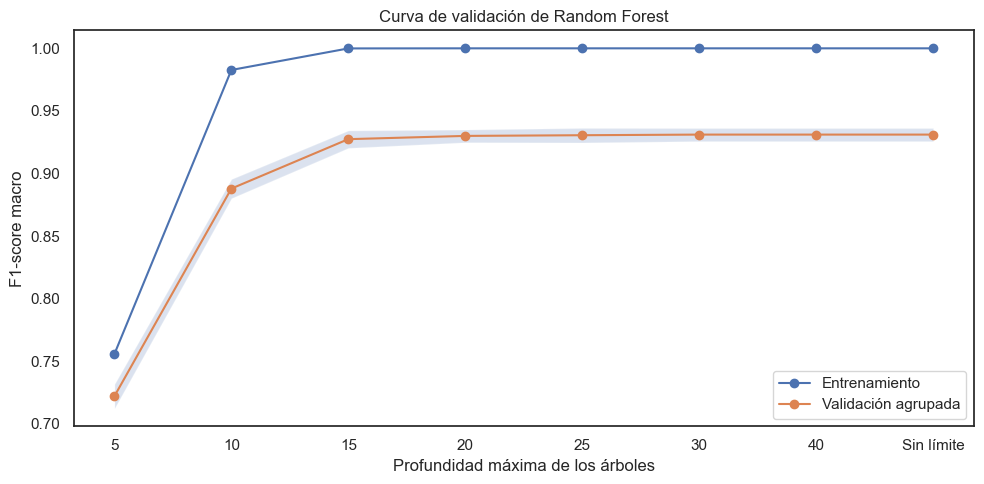

In [7]:
# Profundidades que se evaluarán. None representa árboles sin límite.
profundidades = [5, 10, 15, 20, 25, 30, 40, None]

# Calculamos el desempeño de entrenamiento y validación para cada valor.
puntajes_train, puntajes_validacion = validation_curve(
    estimator=RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    X=X_train,
    y=y_train,
    param_name="max_depth",
    param_range=profundidades,
    groups=grupos_train,
    cv=validacion_cruzada,
    scoring="f1_macro",
    n_jobs=-1
)

# Resumimos los tres folds mediante promedio y desviación estándar.
promedio_train = puntajes_train.mean(axis=1)
desviacion_train = puntajes_train.std(axis=1)

promedio_validacion = puntajes_validacion.mean(axis=1)
desviacion_validacion = puntajes_validacion.std(axis=1)

etiquetas_profundidad = [
    str(valor) if valor is not None else "Sin límite"
    for valor in profundidades
]

tabla_curva = pd.DataFrame({
    "max_depth": etiquetas_profundidad,
    "f1_train": promedio_train,
    "f1_validacion": promedio_validacion,
    "desviacion_validacion": desviacion_validacion
})

display(tabla_curva.round(4))

# Posiciones numéricas para representar también la opción None.
posiciones = np.arange(len(profundidades))

plt.figure(figsize=(10, 5))

plt.plot(
    posiciones,
    promedio_train,
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    posiciones,
    promedio_validacion,
    marker="o",
    label="Validación agrupada"
)

plt.fill_between(
    posiciones,
    promedio_validacion - desviacion_validacion,
    promedio_validacion + desviacion_validacion,
    alpha=0.2
)

plt.xticks(posiciones, etiquetas_profundidad)
plt.title("Curva de validación de Random Forest")
plt.xlabel("Profundidad máxima de los árboles")
plt.ylabel("F1-score macro")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación de la curva

Con `max_depth=5`, el F1 macro fue **0.7558 en entrenamiento** y **0.7221 en validación**, lo que indica subajuste: los árboles son demasiado simples para representar las diferencias entre las actividades. Al aumentar la profundidad, ambos resultados mejoran.

Desde una profundidad de 20, el F1 de entrenamiento llega a **1.0000**, mientras que el F1 de validación continúa aumentando ligeramente: 0.9300 con profundidad 20, 0.9306 con 25 y **0.9311 con 30, 40 y sin límite**. La curva muestra una brecha entre entrenamiento y validación, pero el desempeño de validación no disminuye cuando aumenta la profundidad; se estabiliza.

Usar `max_depth=10` sí reduce la capacidad del modelo, pero no soluciona el problema de manera útil: el F1 de entrenamiento baja a **0.9827** y el de validación también disminuye a **0.8879**, en comparación con **0.9311** sin límite. Esto significa que el modelo se vuelve más simple, pero generaliza peor en los folds de validación. Estos valores no corresponden al conjunto de prueba; la curva utiliza únicamente particiones agrupadas del conjunto de entrenamiento.

Por lo tanto, el resultado perfecto en entrenamiento sí constituye una señal que debe vigilarse, pero esta curva no aporta evidencia de que reducir `max_depth` mejore la generalización. La opción sin límite alcanza el mejor F1 de validación observado, empatada con profundidades 30 y 40. Esto coincide con la búsqueda de hiperparámetros y respalda conservar la configuración inicial.

En conclusión, Random Forest obtuvo **100% en entrenamiento**, por lo que se revisó una posible situación de sobreajuste. No se consideró solamente esa métrica: se realizó validación cruzada agrupada, una búsqueda de hiperparámetros y una curva de validación. La curva mostró una brecha entre entrenamiento y validación, pero el desempeño de validación no disminuyó con árboles más profundos; se estabilizó en un F1 macro de **0.9311**. Además, limitar la profundidad no produjo una mejora. Por ello se conserva la configuración inicial, reconociendo que existe una señal moderada de sobreajuste, pero no evidencia de que la regularización evaluada mejore el modelo.


## 9. Evaluación detallada del modelo seleccionado

La comparación y la revisión de sobreajuste permiten conservar la mejor variante de **Random Forest**. Las métricas generales son útiles para elegir el modelo, pero no muestran si existe alguna actividad específica con un desempeño bajo. Por ello, antes del código se definen las medidas que se utilizarán para evaluarlo con mayor detalle:

- **Precisión por actividad:** indica qué proporción de las predicciones asignadas a una actividad fue correcta. Ayuda a detectar clases a las que el modelo asigna observaciones que pertenecen a otras actividades.
- **Recall por actividad:** indica qué proporción de las observaciones reales de una actividad fue identificada correctamente. Permite encontrar actividades que el modelo no reconoce con suficiente frecuencia.
- **F1-score por actividad:** resume el equilibrio entre precisión y recall para cada clase y facilita identificar las actividades con desempeño más débil.
- **Support:** muestra cuántas observaciones reales de cada actividad existen en el conjunto de prueba. Sirve para interpretar las métricas considerando la cantidad de ejemplos disponibles.
- **Matriz de confusión:** permite observar los aciertos y errores concretos entre pares de actividades. Las filas representan las etiquetas reales y las columnas las predicciones; la diagonal contiene los aciertos y los valores fuera de ella muestran las confusiones.

Este análisis detallado se aplicará solamente a Random Forest porque fue el modelo con mejor resultado en la comparación. Así se evita repetir tablas y gráficas de los modelos descartados y se concentra el diagnóstico en el modelo seleccionado.


,precision,recall,f1-score,support
000,1.0000,0.9931,0.9965,144.0000
001,0.8790,0.9079,0.8932,152.0000
002,0.8864,0.8603,0.8731,136.0000
003,0.9744,0.9500,0.9620,160.0000
004,0.9953,0.9727,0.9839,220.0000
005,0.9696,0.9955,0.9824,224.0000
006,0.9040,0.9524,0.9275,168.0000
007,0.9808,0.9968,0.9887,308.0000
008,0.9912,0.9417,0.9658,240.0000
009,0.9336,0.9795,0.9560,244.0000


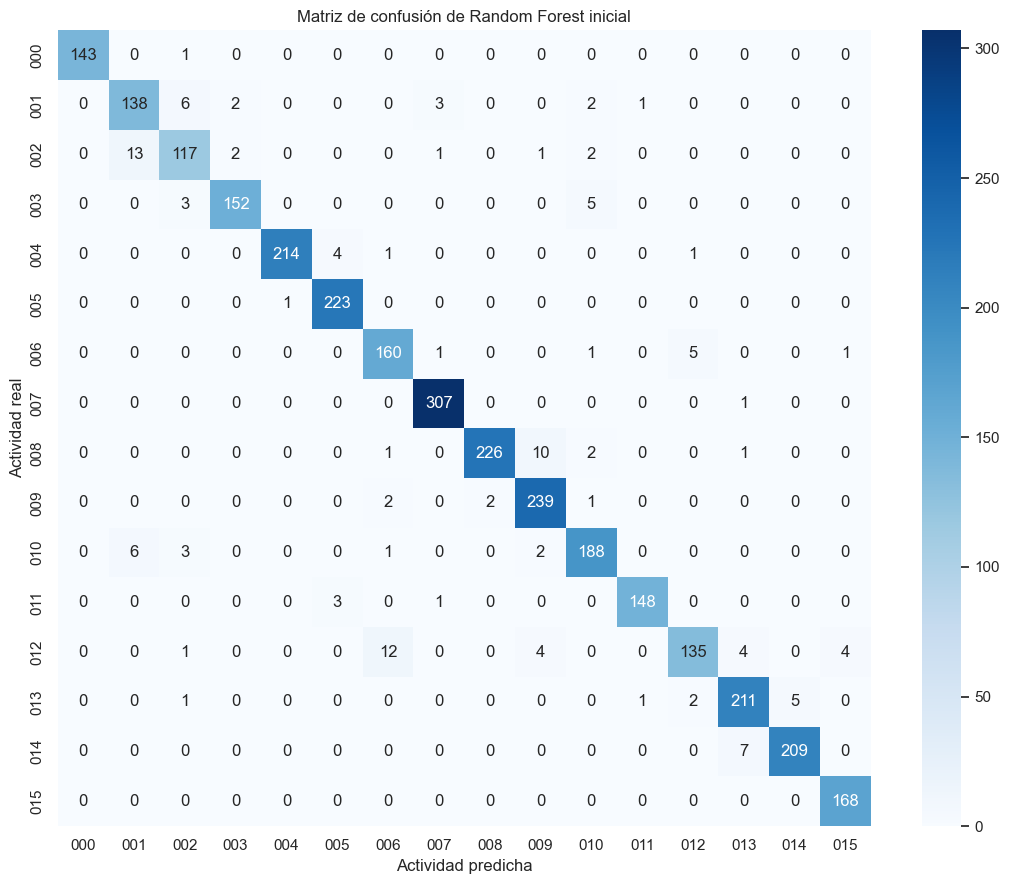

In [8]:
# Recuperamos las predicciones del modelo con mejor resultado.
predicciones_rf = predicciones_rf_final
actividades = np.sort(np.unique(y_test))

# Creamos el reporte de métricas para cada actividad.
reporte_rf = classification_report(
    y_test,
    predicciones_rf,
    labels=actividades,
    output_dict=True,
    zero_division=0
)

tabla_reporte_rf = pd.DataFrame(reporte_rf).transpose()
display(tabla_reporte_rf.round(4))

# Calculamos y mostramos la matriz de confusión.
matriz_rf = confusion_matrix(
    y_test,
    predicciones_rf,
    labels=actividades
)

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actividades,
    yticklabels=actividades
)
plt.title(f"Matriz de confusión de {nombre_rf_final}")
plt.xlabel("Actividad predicha")
plt.ylabel("Actividad real")
plt.tight_layout()
plt.show()


### Interpretación de la evaluación detallada

El reporte confirma que el desempeño es alto en la mayoría de las actividades y que los aciertos se concentran en la diagonal de la matriz. La actividad `000` alcanzó un F1-score de **0.9965**, mientras que `003`, `004`, `005`, `007`, `008`, `011`, `014` y `015` superaron **0.96**.

Las actividades que requieren mayor atención son `002`, con el F1-score más bajo (**0.8731**), y `012`, con el recall más bajo (**0.8438**). Esto significa que Random Forest todavía pierde una proporción mayor de ejemplos reales de `012`. La matriz de confusión permite ubicar hacia qué actividades se desvían esos casos y orientar cambios posteriores en las características o en los parámetros del modelo.


## 10. Decisión final

Con las configuraciones evaluadas, **Random Forest es el modelo seleccionado** porque obtuvo la mayor exactitud (**95.69%**) y el mayor F1-score macro (**0.9529**). También es compatible con la estructura tabular de las 120 características y puede representar las relaciones no lineales que la regresión logística no logró capturar.

La revisión mostró una señal moderada de sobreajuste, ya que el modelo alcanzó 1.0000 en entrenamiento y 0.9569 de exactitud en prueba. Por esa razón se realizó una búsqueda controlada de hiperparámetros y una curva de validación mediante particiones agrupadas, usando únicamente entrenamiento. La curva mostró subajuste con profundidades pequeñas y una estabilización del F1 de validación en **0.9311** desde una profundidad de 30; no mostró una caída al utilizar árboles más profundos. La optimización no superó la configuración original, por lo que se conserva el Random Forest inicial como modelo final.
